In [ ]:
# ── 1. Install dependencies ──────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "supabase", "transformers", "torch", "pandas",
                "matplotlib", "seaborn", "tqdm", "wordcloud"], check=True)
print("All packages ready.")

# Filtering Youtube comment
#We use sentance trasnformers to create emebddings of all the comments and do PCA to simplify it, and K neeartest neighbors

All packages ready.


In [16]:
# ── 2. Imports ────────────────────────────────────────────────────────────────
import re, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from supabase import create_client, Client
from transformers import pipeline

sns.set_theme(style="whitegrid", palette="muted")
print("Imports OK.")

Imports OK.


In [17]:
# ── 3. Fetch ALL rows from Supabase (paginated) ───────────────────────────────
SUPABASE_URL = "https://yxfkplhpjgdwgfabrsrf.supabase.co"
SUPABASE_KEY = "sb_publishable_DTSUBBYxEoDpsH5e9HP40g_Q1YiQKeK"

supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)

PAGE_SIZE = 1000
all_rows  = []
page      = 0

print("Fetching all rows from Supabase ...")
while True:
    start = page * PAGE_SIZE
    end   = start + PAGE_SIZE - 1
    resp  = (
        supabase.table("YoutubeCommentswTimestamp")
        .select("id, video_id, Video_title, Comment_Timestamp, Comment")
        .range(start, end)
        .execute()
    )
    batch = resp.data
    if not batch:
        break
    all_rows.extend(batch)
    print(f"  page {page+1}: fetched {len(batch)} rows  (total so far: {len(all_rows)})")
    if len(batch) < PAGE_SIZE:
        break
    page += 1

raw_df = pd.DataFrame(all_rows)
print(f"\nTotal rows fetched: {len(raw_df)}")
print(raw_df.dtypes)
raw_df.head()

Fetching all rows from Supabase ...
  page 1: fetched 1000 rows  (total so far: 1000)
  page 2: fetched 1000 rows  (total so far: 2000)
  page 3: fetched 1000 rows  (total so far: 3000)
  page 4: fetched 1000 rows  (total so far: 4000)
  page 5: fetched 1000 rows  (total so far: 5000)
  page 6: fetched 1000 rows  (total so far: 6000)
  page 7: fetched 1000 rows  (total so far: 7000)
  page 8: fetched 1000 rows  (total so far: 8000)
  page 9: fetched 1000 rows  (total so far: 9000)
  page 10: fetched 1000 rows  (total so far: 10000)

Total rows fetched: 10000
id                   int64
video_id               str
Video_title            str
Comment_Timestamp      str
Comment                str
dtype: object


,id,video_id,Video_title,Comment_Timestamp,Comment
0,1,fH_mfeKhTbU,AI Therapy Exposed: Clinical Psychologist Revi...,2026-02-28T19:47:48Z,"<a href=""https://www.youtube.com/watch?v=fH_mf..."
1,2,fH_mfeKhTbU,AI Therapy Exposed: Clinical Psychologist Revi...,2026-02-28T19:42:49Z,"<a href=""https://www.youtube.com/watch?v=fH_mf..."
2,3,fH_mfeKhTbU,AI Therapy Exposed: Clinical Psychologist Revi...,2026-02-15T14:31:53Z,I&#39;m not sure how many people talk to their...
3,4,fH_mfeKhTbU,AI Therapy Exposed: Clinical Psychologist Revi...,2026-02-09T09:40:30Z,Feelheard app is ai that listen to you reply w...
4,5,fH_mfeKhTbU,AI Therapy Exposed: Clinical Psychologist Revi...,2026-01-28T13:47:03Z,I tried AI and a regular therapist. I didn’t ...


In [18]:
#data cleaning
# ── 4. Clean & filter ─────────────────────────────────────────────────────────

#Something copilot added to filter out emojis and useless comments
EMOJI_RE    = re.compile(
    "["
    "\U0001F600-\U0001FFFF"   # emoticons
    "\U00002700-\U000027BF"   # dingbats
    "\U0001F300-\U0001F5FF"   # symbols & pictographs
    "\U0001F900-\U0001F9FF"   # supplemental symbols
    "\U0001FA00-\U0001FA6F"   # chess, etc.
    "\U00002600-\U000026FF"   # misc symbols
    "]+", flags=re.UNICODE
)
URL_RE      = re.compile(r'https?://\S+|www\.\S+', re.IGNORECASE)
HANDLE_RE   = re.compile(r'@\w+')

def is_useless(text: str) -> bool:
    """Return True if the comment should be discarded."""
    if not isinstance(text, str):
        return True
    stripped = text.strip()
    # Too short
    if len(stripped) < 10:
        return True
    # After stripping emojis, URLs, handles and punctuation — nothing left?
    cleaned = EMOJI_RE.sub('', stripped)
    cleaned = URL_RE.sub('', cleaned)
    cleaned = HANDLE_RE.sub('', cleaned)
    cleaned = re.sub(r'[^\w\s]', '', cleaned).strip()
    if len(cleaned) < 5:
        return True
    # All digits / numbers only
    if re.fullmatch(r'[\d\s]+', cleaned):
        return True
    return False

df = raw_df.copy()
df['Comment'] = df['Comment'].astype(str).str.strip()

before = len(df)
df = df[~df['Comment'].apply(is_useless)]
df = df.drop_duplicates(subset=['Comment'])
df = df.reset_index(drop=True)
after = len(df)

print(f"Rows before filtering : {before}")
print(f"Rows after  filtering : {after}  ({before - after} removed)")
df.head()

Rows before filtering : 10000
Rows after  filtering : 6561  (3439 removed)


,id,video_id,Video_title,Comment_Timestamp,Comment
0,1,fH_mfeKhTbU,AI Therapy Exposed: Clinical Psychologist Revi...,2026-02-28T19:47:48Z,"<a href=""https://www.youtube.com/watch?v=fH_mf..."
1,2,fH_mfeKhTbU,AI Therapy Exposed: Clinical Psychologist Revi...,2026-02-28T19:42:49Z,"<a href=""https://www.youtube.com/watch?v=fH_mf..."
2,3,fH_mfeKhTbU,AI Therapy Exposed: Clinical Psychologist Revi...,2026-02-15T14:31:53Z,I&#39;m not sure how many people talk to their...
3,4,fH_mfeKhTbU,AI Therapy Exposed: Clinical Psychologist Revi...,2026-02-09T09:40:30Z,Feelheard app is ai that listen to you reply w...
4,5,fH_mfeKhTbU,AI Therapy Exposed: Clinical Psychologist Revi...,2026-01-28T13:47:03Z,I tried AI and a regular therapist. I didn’t ...


In [19]:
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"
print(f"Loading model: {MODEL_NAME}  (download only needed once) ...")
sentiment_pipe = pipeline(
    "sentiment-analysis",
    model=MODEL_NAME,
    truncation=True,
    max_length=512,
    device=-1,          
)
print("Model ready.")

Loading model: cardiffnlp/twitter-roberta-base-sentiment-latest  (download only needed once) ...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2119.74it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model ready.


In [20]:
# ── 5. Run RoBERTa inference in batches ───────────────────────────────────────
BATCH_SIZE = 32

texts  = df['Comment'].tolist()
labels = []
scores = []

for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="RoBERTa inference"):
    batch   = texts[i : i + BATCH_SIZE]
    results = sentiment_pipe(batch)
    for r in results:
        labels.append(r['label'])
        scores.append(round(r['score'], 6))

df['Sentiment_Label'] = labels
df['Sentiment_Score'] = scores

print(f"\nInference done on {len(df)} comments.")
df[['Comment', 'Sentiment_Label', 'Sentiment_Score']].head(10)

RoBERTa inference: 100%|██████████| 206/206 [07:20<00:00,  2.14s/it]


Inference done on 6561 comments.


,Comment,Sentiment_Label,Sentiment_Score
0,"<a href=""https://www.youtube.com/watch?v=fH_mf...",neutral,0.684454
1,"<a href=""https://www.youtube.com/watch?v=fH_mf...",negative,0.690502
2,I&#39;m not sure how many people talk to their...,neutral,0.627270
3,Feelheard app is ai that listen to you reply w...,neutral,0.758615
4,I tried AI and a regular therapist. I didn’t ...,negative,0.875767
5,Watching you chatbot. Is not as helpful as get...,negative,0.911987
6,I&#39;d be really curious for you to do it wit...,neutral,0.502054
7,"What a riot, A computer empathizing with a hu...",positive,0.608415
8,Can you explain why yoyr new videos like they ...,neutral,0.529765
9,Ive gone to several therapists from affordable...,negative,0.898477


In [21]:
# ── 6. Parse timestamps & build monthly time series ──────────────────────────
df['timestamp'] = pd.to_datetime(df['Comment_Timestamp'], utc=True)
df['month']     = df['timestamp'].dt.to_period('M')

monthly = (
    df.groupby(['month', 'Sentiment_Label'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)
# Normalize to proportions for the second chart
monthly_pct = monthly.div(monthly.sum(axis=1), axis=0) * 100

print(f"Date range: {df['timestamp'].min().date()}  →  {df['timestamp'].max().date()}")
print(f"Months in dataset: {len(monthly)}")
monthly.tail()

Date range: 2023-01-27  →  2026-04-16
Months in dataset: 39


/var/folders/cd/v_pss9r947j7_2y9pmccbrj80000gn/T/ipykernel_29656/352972920.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month']     = df['timestamp'].dt.to_period('M')


Sentiment_Label,negative,neutral,positive
month,,,
2025-12,231,91,75
2026-01,92,58,33
2026-02,71,42,30
2026-03,61,37,26
2026-04,25,9,7


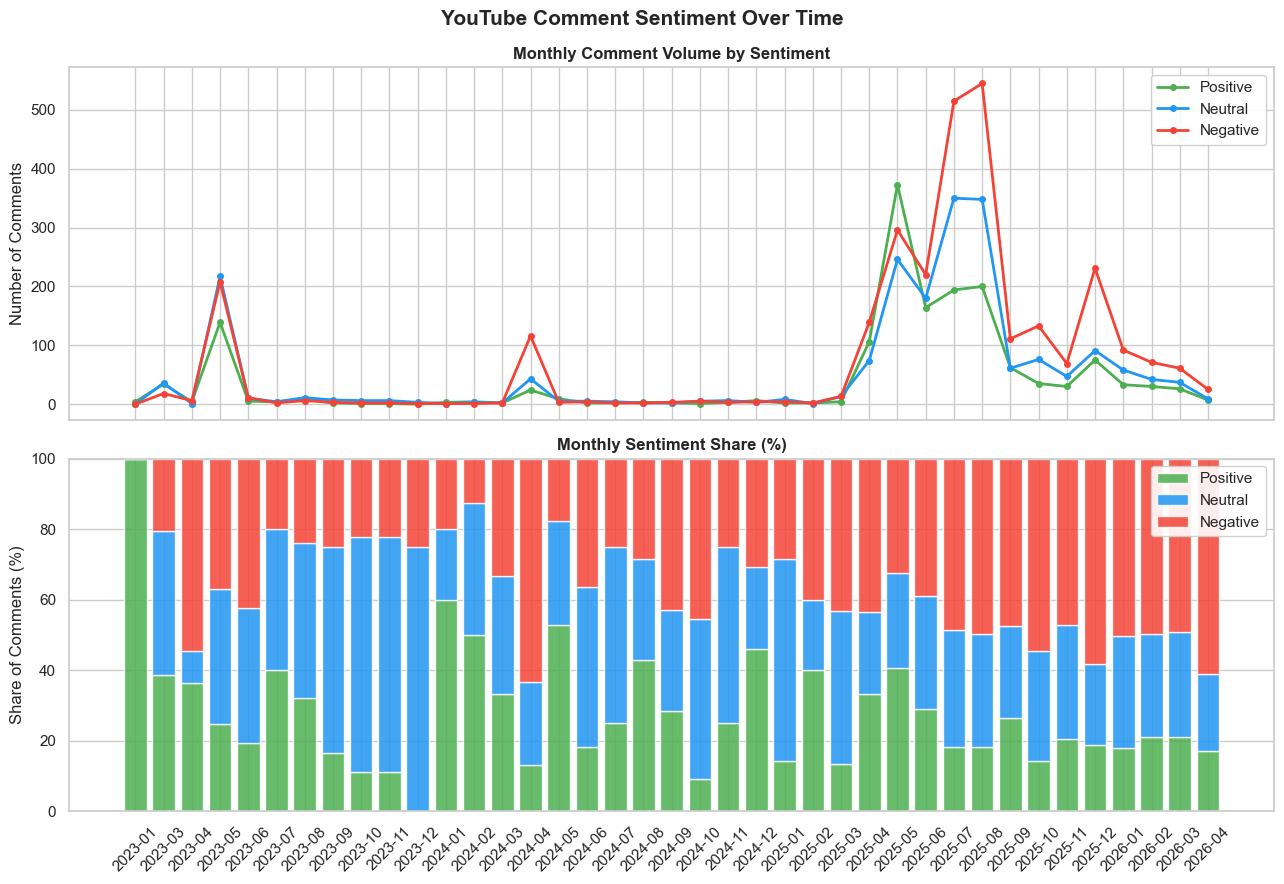

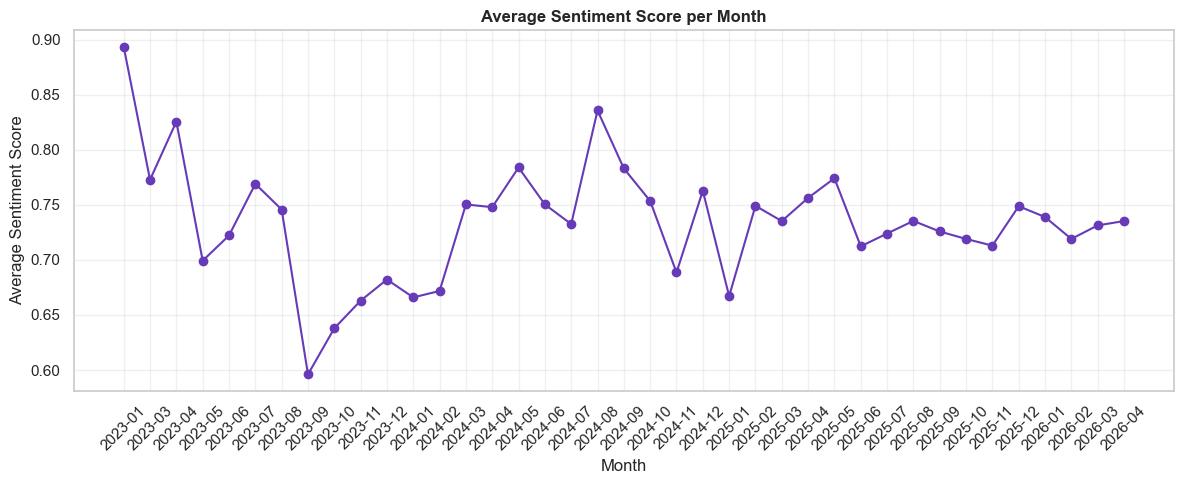

DataFrame size: 6561


In [23]:
# ── 7. Sentiment over time — 2 simple charts ─────────────────────────────────
LABEL_COLORS = {'positive': '#4CAF50', 'neutral': '#2196F3', 'negative': '#F44336'}
ordered      = [l for l in ['positive', 'neutral', 'negative'] if l in monthly.columns]
x_labels     = [str(p) for p in monthly.index]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
fig.suptitle('YouTube Comment Sentiment Over Time', fontsize=15, fontweight='bold')

# ── Chart 1: raw counts per month ─────────────────────────────────────────────
for label in ordered:
    ax1.plot(x_labels, monthly[label], marker='o', markersize=4,
             linewidth=2, color=LABEL_COLORS[label], label=label.capitalize())
ax1.set_ylabel('Number of Comments')
ax1.set_title('Monthly Comment Volume by Sentiment', fontweight='bold')
ax1.legend(framealpha=0.9)

# ── Chart 2: stacked % share per month ────────────────────────────────────────
bottom = np.zeros(len(monthly_pct))
for label in ordered:
    ax2.bar(x_labels, monthly_pct[label], bottom=bottom,
            color=LABEL_COLORS[label], label=label.capitalize(), alpha=0.85)
    bottom += monthly_pct[label].values
ax2.set_ylabel('Share of Comments (%)')
ax2.set_title('Monthly Sentiment Share (%)', fontweight='bold')
ax2.set_ylim(0, 100)
ax2.legend(framealpha=0.9)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#Average sentiment score per month
monthly_score = df.groupby('month')['Sentiment_Score'].mean()
plt.figure(figsize=(12, 5))
plt.plot(monthly_score.index.astype(str), monthly_score.values, marker='o', color='#673AB7')
plt.title('Average Sentiment Score per Month', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Sentiment Score')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("DataFrame size:", df.shape[0])

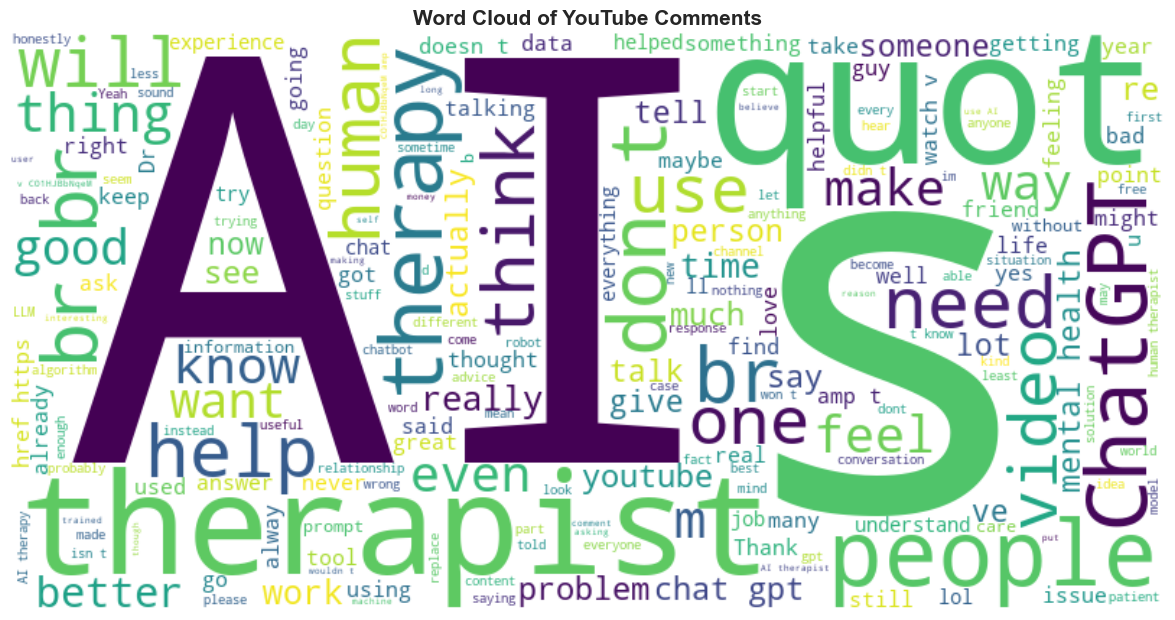

Top 20 words in positive comments:
  ai: 536
  s: 406

Top 20 words in negative comments:
  t: 1189
  ai: 1085
  s: 917
  br: 820
  not: 815


In [30]:
#word cloud generation
from wordcloud import WordCloud
all_text = ' '.join(df['Comment'].tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of YouTube Comments', fontsize=15, fontweight='bold')
plt.show()

#Most common words in positive vs negative comments
from collections import Counter

#Removing filler words from the common words list
filler_words = set(['you', '39', 'i', 'I', 'my', 'me','the', 'and', 'to', 'a', 'is', 'in', 'it', 'of', 'that', 'this', 'for', 'on', 'with', 'as', 'was', 'but', 'are', 'be'])

positive_text = ' '.join(df[df['Sentiment_Label'] == 'positive']['Comment'].tolist())
negative_text = ' '.join(df[df['Sentiment_Label'] == 'negative']['Comment'].tolist())
positive_words = Counter(re.findall(r'\w+', positive_text.lower()))
negative_words = Counter(re.findall(r'\w+', negative_text.lower()))
common_pos = positive_words.most_common(20)
common_neg = negative_words.most_common(20)
print("Top 20 words in positive comments:")

common_pos = [(word, count) for word, count in common_pos if word not in filler_words]
common_neg = [(word, count) for word, count in common_neg if word not in filler_words]
for word, count in common_pos:
    print(f"  {word}: {count}")
print("\nTop 20 words in negative comments:")
for word, count in common_neg:
    print(f"  {word}: {count}") 